# Notebook 05: Monitoring & Learning Agent

Closes the agentic feedback loop: the agent evaluates each pricing decision against simulated operational outcomes and iteratively refines its tariff policy.

**How it works:**
1. A `ChargingEnvironment` simulator acts as the 'live environment' — given a tariff and predicted state, it returns realized demand, utilisation, revenue, congestion penalty, and wait time.
2. A **contextual-bandit / iterative policy** adjusts the tariff multiplier parameters (surge cap, discount floor) based on accumulated reward signal.
3. The loop runs for N episodes; we track all PS-specified monitoring metrics over time.

**Outputs → `outputs/`:**
- `monitoring_metrics.csv`: per-episode Revenue Gain %, Charger Utilisation, Wait Time, Customer Response Rate, Pricing Efficiency Score
- Learning curve figures

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..') / 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from simulator import ChargingEnvironment
from agents import TariffPricingAgent
from metrics import (revenue_gain_pct, avg_wait_time_reduction,
                     customer_response_rate, pricing_efficiency_score,
                     compile_agent_metrics)
from features import BASELINE_TARIFF, SURGE_THRESHOLD, DISCOUNT_THRESHOLD

OUTPUTS = Path('..') / 'outputs'
OUT_FIG = OUTPUTS / 'figures'

sns.set_theme(style='whitegrid', palette='muted')
np.random.seed(42)
print('Ready')

Ready


## 1. Load Demand Predictions (Agent's Input States)

In [2]:
preds = pd.read_csv(OUTPUTS / 'demand_predictions.csv')
# Use UrbanEV test set as the episodic simulation states
states_df = preds[preds['dataset'] == 'urbanev'].copy()
states_df = states_df.dropna(subset=['pred_utilization','pred_load'])
states_df = states_df.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle for episodic sampling
print(f'Simulation states: {len(states_df):,}')

Simulation states: 426,816


/var/folders/q5/qzzxzszs1194f6vdymzlkyqc0000gn/T/ipykernel_31497/1677652168.py:1: DtypeWarning: Columns (0: entity_id) have mixed types. Specify dtype option on import or set low_memory=False.
  preds = pd.read_csv(OUTPUTS / 'demand_predictions.csv')


## 2. Define Learnable Pricing Policy

The policy has two learnable parameters:
- `surge_factor` ∈ [1.0, 1.8]: multiplier applied above the surge threshold
- `discount_factor` ∈ [0.5, 1.0]: multiplier applied below the discount threshold

The feedback loop uses a simple gradient-free hill-climb (coordinate ascent) — clear, reproducible, and directly tracks reward improvement over episodes.

In [3]:
class LearnableTariffPolicy:
    """Tariff policy with learnable surge and discount multipliers."""

    def __init__(self, surge_factor=1.3, discount_factor=0.8):
        self.surge_factor = float(surge_factor)
        self.discount_factor = float(discount_factor)
        self.min_tariff = 9.0
        self.max_tariff = 24.0

    def __call__(self, pred_util: float) -> float:
        if pred_util > SURGE_THRESHOLD:
            t = BASELINE_TARIFF * self.surge_factor
        elif pred_util < DISCOUNT_THRESHOLD:
            t = BASELINE_TARIFF * self.discount_factor
        else:
            # Linear interpolation between discount and surge zones
            frac = (pred_util - DISCOUNT_THRESHOLD) / (SURGE_THRESHOLD - DISCOUNT_THRESHOLD)
            t = BASELINE_TARIFF * (self.discount_factor + frac * (self.surge_factor - self.discount_factor))
        return float(np.clip(t, self.min_tariff, self.max_tariff))

    def clone(self):
        return LearnableTariffPolicy(self.surge_factor, self.discount_factor)


print('Policy defined.')

Policy defined.


## 3. Run Episodic Feedback Loop

In [4]:
def run_episode(policy, env, states_df, batch_size=200, seed=None):
    """Run one evaluation episode over a random batch of states."""
    rng = np.random.default_rng(seed)
    batch_idx = rng.choice(len(states_df), size=batch_size, replace=False)
    batch = states_df.iloc[batch_idx].reset_index(drop=True)

    results = []
    for _, row in batch.iterrows():
        state = {
            'pred_utilization': row['pred_utilization'],
            'baseline_demand': max(row['pred_load'], 0.1),
            'capacity': max(row['pred_load'], 0.1) / max(row['pred_utilization'], 0.01),
        }
        tariff = policy(row['pred_utilization'])
        outcome = env.step(state, tariff)
        outcome['baseline_revenue'] = row['pred_load'] * BASELINE_TARIFF
        outcome['pred_utilization'] = row['pred_utilization']
        results.append(outcome)

    df = pd.DataFrame(results)
    total_rev = df['revenue'].sum()
    baseline_rev = df['baseline_revenue'].sum()
    return {
        'total_reward': df['reward'].sum(),
        'revenue_gain_pct': revenue_gain_pct(total_rev, baseline_rev),
        'mean_realized_util': df['realized_util'].mean(),
        'mean_wait_time': df['wait_time_proxy'].mean(),
        'pricing_efficiency': pricing_efficiency_score(df['revenue'].values,
                                                       df['realized_demand'].values).mean(),
        'surge_factor': getattr(policy, 'surge_factor', float('nan')),
        'discount_factor': getattr(policy, 'discount_factor', float('nan')),
    }


print('Episode runner defined.')

Episode runner defined.


In [5]:
# Estimate elasticity from UrbanEV for the simulator
tariff_metrics = pd.read_csv(OUTPUTS / 'tariff_metrics.csv')
elasticity = float(tariff_metrics['elasticity_used'].iloc[0])
print(f'Using elasticity ε = {elasticity:.4f}')

env = ChargingEnvironment(elasticity=elasticity, noise_std=0.05, seed=42)

# Initial policy
policy = LearnableTariffPolicy(surge_factor=1.3, discount_factor=0.8)

# Baseline (fixed ₹15)
class FixedPolicy:
    def __call__(self, u): return BASELINE_TARIFF

baseline_policy = FixedPolicy()
baseline_ep = run_episode(baseline_policy, env, states_df, batch_size=500, seed=0)
print(f'Baseline episode reward: {baseline_ep["total_reward"]:.2f}')
print(f'Baseline Revenue Gain%: {baseline_ep["revenue_gain_pct"]:+.2f}%')

Using elasticity ε = -2.0188
Baseline episode reward: 290800.38
Baseline Revenue Gain%: -0.25%


In [6]:
N_EPISODES = 40
STEP_SIZES = [0.05, 0.025, 0.01]  # coordinate ascent step sizes
BATCH_SIZE = 300

episode_log = []
best_reward = -np.inf
best_policy = policy.clone()

current_reward = run_episode(policy, env, states_df, BATCH_SIZE, seed=1)['total_reward']

for ep in range(N_EPISODES):
    step = STEP_SIZES[min(ep // 15, len(STEP_SIZES)-1)]

    # Try perturbing surge_factor
    for delta in [step, -step]:
        candidate = policy.clone()
        candidate.surge_factor = float(np.clip(candidate.surge_factor + delta, 1.0, 1.8))
        r = run_episode(candidate, env, states_df, BATCH_SIZE, seed=ep+100)['total_reward']
        if r > current_reward:
            policy = candidate
            current_reward = r
            break

    # Try perturbing discount_factor
    for delta in [step, -step]:
        candidate = policy.clone()
        candidate.discount_factor = float(np.clip(candidate.discount_factor + delta, 0.5, 1.0))
        r = run_episode(candidate, env, states_df, BATCH_SIZE, seed=ep+200)['total_reward']
        if r > current_reward:
            policy = candidate
            current_reward = r
            break

    ep_metrics = run_episode(policy, env, states_df, BATCH_SIZE, seed=ep+300)
    ep_metrics['episode'] = ep + 1
    ep_metrics['step_size'] = step
    episode_log.append(ep_metrics)

    if ep_metrics['total_reward'] > best_reward:
        best_reward = ep_metrics['total_reward']
        best_policy = policy.clone()

    if (ep+1) % 10 == 0:
        print(f'  Episode {ep+1:3d}: reward={ep_metrics["total_reward"]:8.2f} | '
              f'revenue_gain={ep_metrics["revenue_gain_pct"]:+.2f}% | '
              f'surge={policy.surge_factor:.3f} | discount={policy.discount_factor:.3f}')

print(f'\nBest policy: surge_factor={best_policy.surge_factor:.3f}, discount_factor={best_policy.discount_factor:.3f}')
print(f'Best reward: {best_reward:.2f}')

  Episode  10: reward=207801.73 | revenue_gain=+4.46% | surge=1.300 | discount=0.800


  Episode  20: reward=166216.31 | revenue_gain=+7.48% | surge=1.300 | discount=0.825


  Episode  30: reward=212017.13 | revenue_gain=+1.70% | surge=1.300 | discount=0.825


  Episode  40: reward=181461.97 | revenue_gain=+6.64% | surge=1.310 | discount=0.825

Best policy: surge_factor=1.300, discount_factor=0.825
Best reward: 244324.56


## 4. All Monitoring Metrics — Final Evaluation Episode

In [7]:
# Large final evaluation: best learned policy vs baseline
FINAL_BATCH = 1000

# Evaluate baseline
rng = np.random.default_rng(999)
batch_idx = rng.choice(len(states_df), size=FINAL_BATCH, replace=False)
batch = states_df.iloc[batch_idx].reset_index(drop=True)

baseline_outcomes, learned_outcomes = [], []
for _, row in batch.iterrows():
    state = {
        'pred_utilization': row['pred_utilization'],
        'baseline_demand': max(row['pred_load'], 0.1),
        'capacity': max(row['pred_load'], 0.1) / max(row['pred_utilization'], 0.01),
    }
    baseline_outcomes.append(env.step(state, BASELINE_TARIFF))
    learned_tariff = best_policy(row['pred_utilization'])
    learned_outcomes.append(env.step(state, learned_tariff))

b_df = pd.DataFrame(baseline_outcomes)
l_df = pd.DataFrame(learned_outcomes)

print('=== Final Evaluation Metrics ===')
print(f'Revenue Gain % (best policy vs baseline):  {revenue_gain_pct(l_df["revenue"].sum(), b_df["revenue"].sum()):+.2f}%')
print(f'Charger Utilisation — baseline:            {b_df["realized_util"].mean():.3f}')
print(f'Charger Utilisation — learned:             {l_df["realized_util"].mean():.3f}')
print(f'Avg Wait Time — baseline (min):            {b_df["wait_time_proxy"].mean():.3f}')
print(f'Avg Wait Time — learned (min):             {l_df["wait_time_proxy"].mean():.3f}')
print(f'Wait Time Reduction:                       {avg_wait_time_reduction(b_df["wait_time_proxy"].values, l_df["wait_time_proxy"].values):.3f} min')
print(f'Pricing Efficiency (baseline ₹/kWh):       {pricing_efficiency_score(b_df["revenue"].values, b_df["realized_demand"].values).mean():.3f}')
print(f'Pricing Efficiency (learned ₹/kWh):        {pricing_efficiency_score(l_df["revenue"].values, l_df["realized_demand"].values).mean():.3f}')
crr = customer_response_rate(
    b_df['realized_demand'].values, l_df['realized_demand'].values,
    np.full(FINAL_BATCH, BASELINE_TARIFF),
    np.array([best_policy(u) for u in batch['pred_utilization']])
)
print(f'Customer Response Rate (sessions/₹):       {crr:.4f}')

=== Final Evaluation Metrics ===
Revenue Gain % (best policy vs baseline):  +0.67%
Charger Utilisation — baseline:            0.304
Charger Utilisation — learned:             0.352
Avg Wait Time — baseline (min):            0.032
Avg Wait Time — learned (min):             0.000
Wait Time Reduction:                       0.032 min
Pricing Efficiency (baseline ₹/kWh):       15.000
Pricing Efficiency (learned ₹/kWh):        13.427
Customer Response Rate (sessions/₹):       -6.9492


## 5. Learning Curve Visualisations

/var/folders/q5/qzzxzszs1194f6vdymzlkyqc0000gn/T/ipykernel_31497/2785966452.py:39: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/q5/qzzxzszs1194f6vdymzlkyqc0000gn/T/ipykernel_31497/2785966452.py:40: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.savefig(OUT_FIG / 'monitoring_learning_curves.png', dpi=150)


/Users/prnb/Desktop/socbiz/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


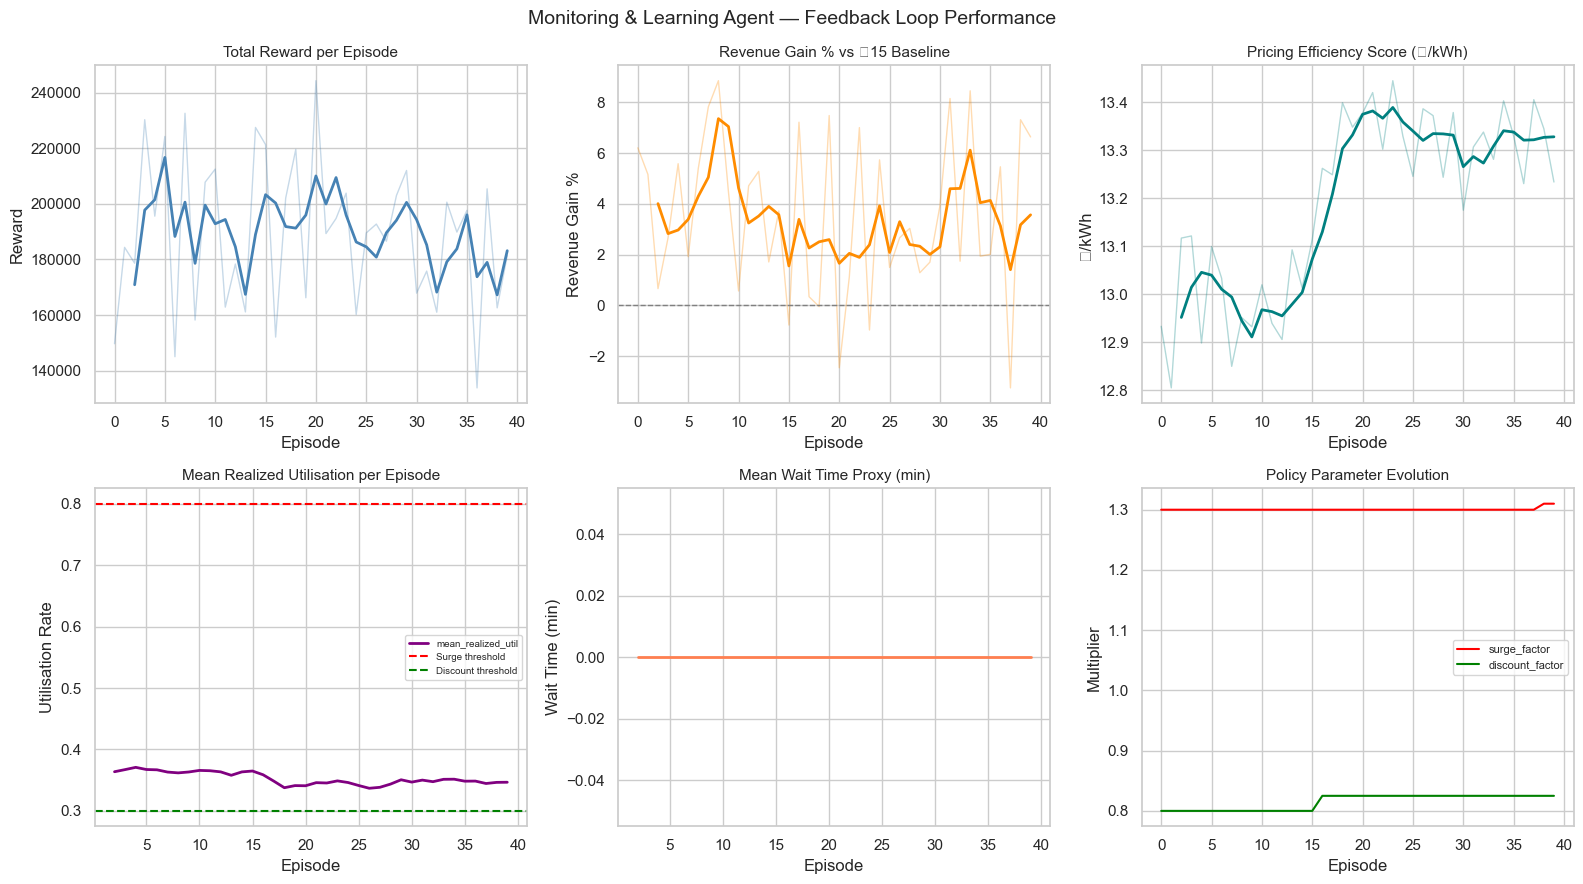

In [8]:
ep_df = pd.DataFrame(episode_log)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

ep_df['total_reward'].rolling(3).mean().plot(ax=axes[0,0], color='steelblue', lw=2)
ep_df['total_reward'].plot(ax=axes[0,0], color='steelblue', alpha=0.3, lw=1)
axes[0,0].set_title('Total Reward per Episode', fontsize=11)
axes[0,0].set_xlabel('Episode'); axes[0,0].set_ylabel('Reward')

ep_df['revenue_gain_pct'].rolling(3).mean().plot(ax=axes[0,1], color='darkorange', lw=2)
ep_df['revenue_gain_pct'].plot(ax=axes[0,1], color='darkorange', alpha=0.3, lw=1)
axes[0,1].axhline(0, color='grey', linestyle='--', lw=1)
axes[0,1].set_title('Revenue Gain % vs ₹15 Baseline', fontsize=11)
axes[0,1].set_xlabel('Episode'); axes[0,1].set_ylabel('Revenue Gain %')

ep_df['pricing_efficiency'].rolling(3).mean().plot(ax=axes[0,2], color='teal', lw=2)
ep_df['pricing_efficiency'].plot(ax=axes[0,2], color='teal', alpha=0.3, lw=1)
axes[0,2].set_title('Pricing Efficiency Score (₹/kWh)', fontsize=11)
axes[0,2].set_xlabel('Episode'); axes[0,2].set_ylabel('₹/kWh')

ep_df['mean_realized_util'].rolling(3).mean().plot(ax=axes[1,0], color='purple', lw=2)
axes[1,0].axhline(SURGE_THRESHOLD, color='red', linestyle='--', lw=1.5, label='Surge threshold')
axes[1,0].axhline(DISCOUNT_THRESHOLD, color='green', linestyle='--', lw=1.5, label='Discount threshold')
axes[1,0].set_title('Mean Realized Utilisation per Episode', fontsize=11)
axes[1,0].set_xlabel('Episode'); axes[1,0].set_ylabel('Utilisation Rate')
axes[1,0].legend(fontsize=7)

ep_df['mean_wait_time'].rolling(3).mean().plot(ax=axes[1,1], color='coral', lw=2)
axes[1,1].set_title('Mean Wait Time Proxy (min)', fontsize=11)
axes[1,1].set_xlabel('Episode'); axes[1,1].set_ylabel('Wait Time (min)')

axes[1,2].plot(ep_df['surge_factor'], label='surge_factor', color='red')
axes[1,2].plot(ep_df['discount_factor'], label='discount_factor', color='green')
axes[1,2].set_title('Policy Parameter Evolution', fontsize=11)
axes[1,2].set_xlabel('Episode'); axes[1,2].set_ylabel('Multiplier')
axes[1,2].legend(fontsize=8)

plt.suptitle('Monitoring & Learning Agent — Feedback Loop Performance', fontsize=14)
plt.tight_layout()
plt.savefig(OUT_FIG / 'monitoring_learning_curves.png', dpi=150)
plt.show()

## 6. Export Monitoring Metrics

In [9]:
ep_df.to_csv(OUTPUTS / 'monitoring_metrics.csv', index=False)
print(f'Saved monitoring_metrics.csv: {len(ep_df)} episodes')

# Final summary metrics
summary = {
    'revenue_gain_pct_final': revenue_gain_pct(l_df['revenue'].sum(), b_df['revenue'].sum()),
    'charger_util_baseline': b_df['realized_util'].mean(),
    'charger_util_learned': l_df['realized_util'].mean(),
    'wait_time_reduction_min': avg_wait_time_reduction(b_df['wait_time_proxy'].values, l_df['wait_time_proxy'].values),
    'pricing_efficiency_baseline': pricing_efficiency_score(b_df['revenue'].values, b_df['realized_demand'].values).mean(),
    'pricing_efficiency_learned': pricing_efficiency_score(l_df['revenue'].values, l_df['realized_demand'].values).mean(),
    'customer_response_rate': crr,
    'best_surge_factor': best_policy.surge_factor,
    'best_discount_factor': best_policy.discount_factor,
    'n_episodes': N_EPISODES,
}
pd.DataFrame([summary]).to_csv(OUTPUTS / 'monitoring_summary.csv', index=False)
print('Saved monitoring_summary.csv')
print('\n=== Final Monitoring Summary ===')
for k, v in summary.items():
    print(f'  {k:45}: {v:.4f}' if isinstance(v, float) else f'  {k:45}: {v}')

Saved monitoring_metrics.csv: 40 episodes
Saved monitoring_summary.csv

=== Final Monitoring Summary ===
  revenue_gain_pct_final                       : 0.6691
  charger_util_baseline                        : 0.3041
  charger_util_learned                         : 0.3521
  wait_time_reduction_min                      : 0.0323
  pricing_efficiency_baseline                  : 15.0000
  pricing_efficiency_learned                   : 13.4266
  customer_response_rate                       : -6.9492
  best_surge_factor                            : 1.3000
  best_discount_factor                         : 0.8250
  n_episodes                                   : 40
